Loading data...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)


--- STAGE 1: BASE TRAINING (8 EPOCHS) ---
Epoch 1/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9364 - loss: 0.2118 - val_accuracy: 0.9578 - val_loss: 0.1320
Epoch 2/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9739 - loss: 0.0865 - val_accuracy: 0.9752 - val_loss: 0.0790
Epoch 3/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9824 - loss: 0.0566 - val_accuracy: 0.9778 - val_loss: 0.0762
Epoch 4/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9856 - loss: 0.0450 - val_accuracy: 0.9773 - val_loss: 0.0775
Epoch 5/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9894 - loss: 0.0331 - val_accuracy: 0.9758 - val_loss: 0.0818
Epoch 6/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9897 - loss: 0.0308 - val_accuracy: 0.9727 - val_loss: 0.1002
Epoch 7/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9915 - loss: 0.0258 - val_accuracy: 0.9810 - val_loss: 0.0784
Epoch 8/8
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.993

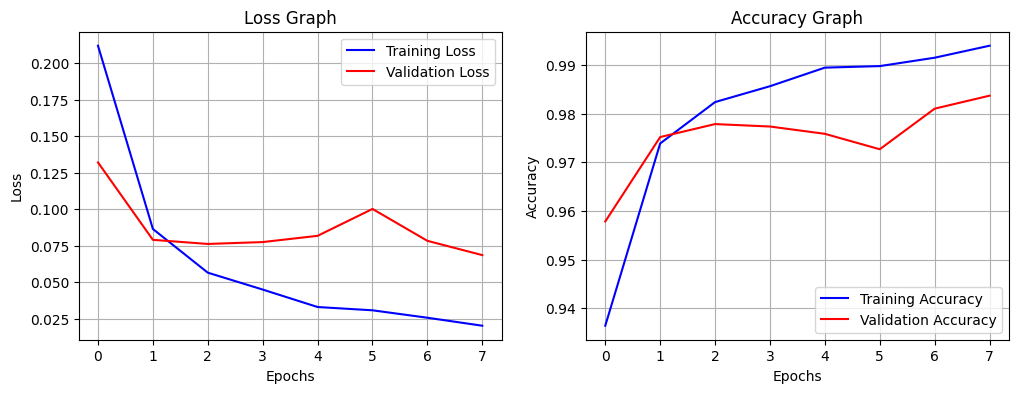


--- STAGE 2: FINE-TUNING ---
Epoch 1/3
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.9722 - loss: 0.1063 - val_accuracy: 0.9750 - val_loss: 0.0720
Epoch 2/3
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9806 - loss: 0.0712 - val_accuracy: 0.9750 - val_loss: 0.0748
Epoch 3/3
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9850 - loss: 0.0484 - val_accuracy: 0.9800 - val_loss: 0.0709

--- STAGE 3: FINAL TESTING ---
250/250 - 1s - 4ms/step - accuracy: 0.9830 - loss: 0.0634
Final accuracy of the improved MLP: 98.30%


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt

# ==========================================
# 1. DATA LOADING AND PREPARATION
# ==========================================
print("Loading data...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# ==========================================
# 2. ARCHITECTURE (Improved "Pure" MLP)
# ==========================================
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),

    # Layer 1: Wide layer to capture all details
    layers.Dense(512, activation='relu', kernel_initializer='he_normal'),

    # Layer 2: Narrowing down (forces the network to generalize data)
    layers.Dense(256, activation='relu', kernel_initializer='he_normal'),

    # Layer 3: Final abstraction before output
    layers.Dense(128, activation='relu', kernel_initializer='he_normal'),

    # Output layer (10 digits)
    layers.Dense(10, activation='softmax')
])

model.summary()

# ==========================================
# 3. STAGE 1: BASE TRAINING
# ==========================================
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\n--- STAGE 1: BASE TRAINING (8 EPOCHS) ---")
# Training a bit longer to see the network's limits
history = model.fit(x_train, y_train, epochs=8, batch_size=64, validation_split=0.1)

# ==========================================
# 4. PLOTTING THE GRAPHS
# ==========================================
plt.figure(figsize=(12, 4))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

# ==========================================
# 5. STAGE 2: FINE-TUNING (Continuing Backprop)
# ==========================================
print("\n--- STAGE 2: FINE-TUNING ---")

# Taking some "new" data for fine-tuning
x_new_data = x_test[:2000]
y_new_data = y_test[:2000]

# Decreasing the learning rate to carefully continue backpropagation
custom_optimizer = optimizers.Adam(learning_rate=0.0001)

model.compile(optimizer=custom_optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_fine = model.fit(x_new_data, y_new_data, epochs=3, batch_size=64, validation_split=0.1)

# ==========================================
# 6. FINAL TESTING
# ==========================================
print("\n--- STAGE 3: FINAL TESTING ---")
x_final_test = x_test[2000:]
y_final_test = y_test[2000:]
test_loss, test_acc = model.evaluate(x_final_test, y_final_test, verbose=2)
print(f'Final accuracy of the improved MLP: {test_acc * 100:.2f}%')